In [1]:
# Please write the name of the enironment here next time onwards

import subprocess
import pyautogui
from mss import mss
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import pytesseract
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'
import pygetwindow as gw
import time

In [3]:
import random

In [4]:
def start_game():
    command = "start java App"  # Replace with your actual command
    subprocess.run(command, shell=True)

def focus_game_window(title):
    window = gw.getWindowsWithTitle(title)[0]
    if window != []:
        try:
            window.activate()
        except:
            window.minimize()
            window.restore()

def close_game(title):
    try:
        game_window = gw.getWindowsWithTitle(title)[0]  # Adjust the title accordingly
        if game_window:
            game_window.close()
            time.sleep(0.5)  # Give some time for the window to close
    except Exception as e:
        print(f"Error closing window: {e}")

def restart_game():
    # Press the Spacebar
    pyautogui.press('space')
    
#if game_has_ended():  # You need to implement this function
#    restart_game()

def get_window_by_exact_title(title):
    windows = gw.getWindowsWithTitle(title)
    for window in windows:
        if window.title == title:
            return window
    return None

def get_window_dimensions(title):
    window = get_window_by_exact_title(title)  # Get the window with the specified title
    if window:
        return window.left+5, window.top+40, window.left+window.width-5, window.top+window.height-5
    else:
        return None

In [8]:
# Example usage
start_game()
time.sleep(2)
dimensions = get_window_dimensions("Snake")  # Replace with your window's title
if dimensions:
    print("Window position and size:", dimensions)
else:
    print("Window not found.")

Window position and size: (590, 175, 1347, 926)


In [29]:
def get_head_coordinates(opencv_image):
    print(opencv_image.shape)
    print(opencv_image[2].shape)
    # Verify that opencv_image is a valid image
    if opencv_image is None or len(opencv_image.shape) != 3 or opencv_image.shape[2] != 3:
        raise ValueError("Invalid image data")

    # Define the BGR color for the snake's head
    head_color = np.array([0, 150, 0], dtype=np.uint8)

    # Perform elementwise comparison
    mask = np.all(opencv_image == head_color, axis=2)

    # Find the coordinates of the head color
    Y, X = np.where(mask)

    # Check if any head color pixel is found
    if len(Y) > 0 and len(X) > 0:
        return X[0], Y[0]
    else:
        return None, None


def get_food_coordinates(opencv_image):
    print(opencv_image.shape)
    print(opencv_image[2].shape)
    # Define the BGR color for the food
    if opencv_image is None or len(opencv_image.shape) != 3 or opencv_image.shape[2] != 3:
        raise ValueError("Invalid image data")

    # Define the BGR color for the snake's head
    food_color = np.array([0, 0, 255])

    # Perform elementwise comparison
    mask = np.all(opencv_image == food_color, axis=2)

    # Find the coordinates of the head color
    Y, X = np.where(mask)

    # Check if any head color pixel is found
    if len(Y) > 0 and len(X) > 0:
        return X[0], Y[0]
    else:
        return None, None


In [36]:
def capture_screen(region=None):
    with mss() as sct:
        # The screen part to capture
        monitor = region if region else sct.monitors[1]  # Default to the entire screen
        screenshot = sct.grab(monitor)
        img = np.array(screenshot)
        img = img[:, :, :3]
        print(type(img))
        food_x, food_y = get_food_coordinates(img)
        head_x, head_y = get_head_coordinates(img)

        if food_x is None:
            food_x = 1  # Replace with a suitable default
        if food_y is None:
            food_y = 1
        if head_x is None:
            head_x = 1
        if head_y is None:
            head_y = 1

        # Convert to a format suitable for Matplotlib (remove alpha channel)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        return img, food_x+region[0], food_y+region[1], head_x+region[0], head_y+region[1]

def display_image(img):
    if img is None or not isinstance(img, np.ndarray):
        print("No image to display.")
        return
    plt.imshow(img, aspect='auto')
    plt.show()

def analyze_game_state(img):
    text = pytesseract.image_to_string(img[0][:35, :200])
#     display_image(img[:35, :200])
    if "Score" in text:
        return "In Progress",text
    else:
        return "Game Over", text

def get_score_from_text(text):
    score = ''.join([char for char in text if char.isdigit()])
    return int(score)

In [11]:
l = get_score_from_text("Score: 123|4\n")
l

1234

<class 'numpy.ndarray'>
(751, 757, 3)
(757, 3)
(751, 757, 3)
(757, 3)
Shape = (751, 757)


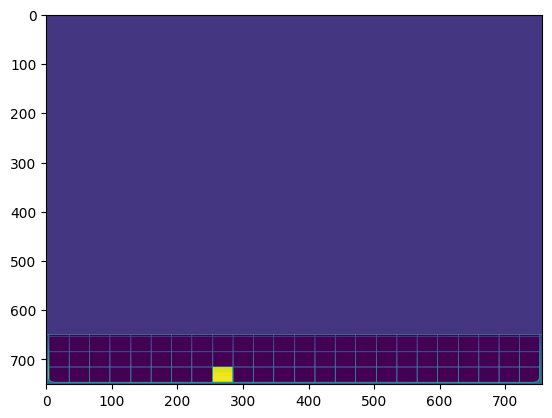

(751, 757)
(757,)


ValueError: Invalid image data

In [32]:
start_game()
time.sleep(2)
img = None
for i in range(10):
    img = capture_screen(dimensions)
    print("Shape = "+str(img[0].shape))
    display_image(img[0])
    print(get_head_coordinates(img[0]))
    print(get_food_coordinates(img[0]))
    game_state, text = analyze_game_state(img[0])
    print(game_state, text)


In [128]:
img.shape

(751, 757, 3)

In [7]:
start_game()
time.sleep(2)
dimensions = get_window_dimensions("Snake")  # Replace with your window's title
get_food_coordinates()

In [8]:
dimensions

(590, 175, 1347, 926)

In [33]:
def make_move(idx):
    moves = ['up', 'down', 'left', 'right']
    pyautogui.press(moves[idx])

In [34]:
def game_loop():
    # Start the game
    start_game()
    time.sleep(2)  # Wait for the game to open
    img = None

    while True:
        window = get_window_by_exact_title('Snake')
        if window == None:
            break  # Exit the loop if no windows are found

        img = capture_screen(dimensions)
        
        game_state, text = analyze_game_state(img)

        if game_state == "Game Over":
            restart_game() 
   
        elif game_state == "In Progress":
            # Game-playing logic
            idx = random.randint(0,3)
            print('Move - ', str(idx))
            make_move(idx)
            score = get_score_from_text(text)
            print('Score: ' + str(score))
            display_image(img)
            print(get_head_coordinates(img))

        else:
            # Unknown state
            print(game_state, text)


In [37]:
game_loop()

<class 'numpy.ndarray'>
(751, 757, 3)
(757, 3)
(751, 757, 3)
(757, 3)
Move -  3
Score: 0
No image to display.


AttributeError: 'tuple' object has no attribute 'shape'

In [66]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [127]:
import torch
import torch.nn as nn
import torch.optim as optim

class DQN(nn.Module):
    def __init__(self, h, w, outputs, num_additional_inputs):
        super(DQN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=5, stride=2)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, stride=2)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 32, kernel_size=5, stride=2)
        self.bn3 = nn.BatchNorm2d(32)

        def conv2d_size_out(size, kernel_size=5, stride=2):
            return (size - (kernel_size - 1) - 1) // stride + 1

        convw = conv2d_size_out(conv2d_size_out(conv2d_size_out(w)))
        convh = conv2d_size_out(conv2d_size_out(conv2d_size_out(h)))
        linear_input_size = convw * convh * 32

         # Additional input pathway
        self.fc1 = nn.Linear(linear_input_size + num_additional_inputs, 64)

        #Output layer
        self.head = nn.Linear(64, outputs)

    def forward(self, x, additional_inputs):
        # Convolutional pathway
        x = x.to(torch.float32) / 255  # Normalize pixel values
        x = nn.functional.relu(self.bn1(self.conv1(x)))
        x = nn.functional.relu(self.bn2(self.conv2(x)))
        x = nn.functional.relu(self.bn3(self.conv3(x)))
        x = x.view(x.size(0), -1)

        print("From the forward prop: ", str(x.dim()), str(additional_inputs.dim()))
        assert x.dim() == 2 and additional_inputs.dim() == 2, "Incorrect input dimensions"

        # Combine conv output with additional inputs
        combined = torch.cat((x, additional_inputs), dim=1)
        combined = nn.functional.relu(self.fc1(combined))
        return self.head(combined)


In [68]:
import cv2
import numpy as np

def preprocess_image(image, height, width):
    image = cv2.resize(image, (width, height))
    image = np.expand_dims(image, axis=0)  # Add channel dimension
    image = image / 255.0
    
    # Convert to PyTorch tensor and add batch dimension (NCHW format)
    return torch.from_numpy(image).unsqueeze(0).float()


In [129]:
import random
from collections import namedtuple, deque

Experience = namedtuple('Experience', ('image_input', 'additional_input', 'action', 'next_image_input', 'next_additional_input', 'reward', 'done'))

class ReplayMemory(object):
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, image_input, additional_input, action, next_image_input, next_additional_input, reward, done):
        self.memory.append(Experience(image_input, additional_input, action, next_image_input, next_additional_input, reward, done))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)



In [117]:
def select_action(state, policy_net, epsilon):
    sample = random.random()
    image_input, additional_inputs = state

    if sample > epsilon:
        with torch.no_grad():
            # Check if batch dimension is already present
            if additional_inputs.dim() != 2:
                additional_inputs = additional_inputs.unsqueeze(0) if additional_inputs.dim() == 1 else additional_inputs
            return policy_net(image_input, additional_inputs).max(1)[1].view(1, 1)
    else:
        return torch.tensor([[random.randrange(num_actions)]], device=device, dtype=torch.long)

In [145]:
def optimize_model(policy_net, target_net, replay_memory, optimizer):
    GAMMA = 0.90
    if len(replay_memory) < BATCH_SIZE:
        return

    transitions = replay_memory.sample(BATCH_SIZE)
    batch = Experience(*zip(*transitions))

     # Separate and concatenate the components of the states and next states
    state_images, state_additional = zip(*[(exp.image_input, exp.additional_input) for exp in transitions])
    state_images = torch.cat([img.unsqueeze(0) if img.dim() == 3 else img for img in state_images])  # Ensure correct shape
    state_additional = torch.cat([add.unsqueeze(0) if add.dim() == 1 else add for add in state_additional])  # Ensure 1D vectors

    action_batch = torch.cat([exp.action for exp in transitions])
    reward_batch = torch.cat([exp.reward for exp in transitions])

    non_final_next_states = [(exp.next_image_input, exp.next_additional_input) for exp in transitions if exp.next_image_input is not None]
    
    non_final_mask = torch.tensor([s is not None for s, _ in non_final_next_states], dtype=torch.bool, device=device)

    if non_final_next_states:
        non_final_next_images, non_final_next_additional = zip(*non_final_next_states)
        non_final_next_images = torch.cat([img.unsqueeze(0) if img.dim() == 3 else img for img in non_final_next_images])
        non_final_next_additional = torch.cat([add.unsqueeze(0) if add.dim() == 1 else add for add in non_final_next_additional])
    else:
        non_final_next_images = torch.zeros(0, 1, image_height, image_width, device=device)
        non_final_next_additional = torch.zeros(0, 4, device=device)

    # Compute Q values for the current states
    state_action_values = policy_net(state_images, state_additional).gather(1, action_batch)

    # Compute V(s_{t+1}) for all next states
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    if non_final_next_states:
        next_state_values[non_final_mask] = target_net(non_final_next_images, non_final_next_additional).max(1)[0].detach()

    # Compute the expected Q values
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    # Compute loss
    loss = F.smooth_l1_loss(state_action_values, expected_state_action_values.unsqueeze(1))

    # Optimize the model
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()


In [72]:
# Check if a GPU is available and use it; otherwise, use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [73]:
device

device(type='cuda')

In [74]:
import itertools
import torch.nn.functional as F

In [170]:
EPSILON_START = 0.99  # High initial value for more exploration
EPSILON_END = 0.05   # Lower bound on EPSILON for eventual exploitation
EPSILON_DECAY = 5000  # Number of steps over which to decay EPSILON
EPSILON = EPSILON_START

In [163]:
def calculate_reward(previous_score, new_score, distance_before, distance_after, game_over):
    if game_over:
        return -10  # Penalty for losing the game
    elif new_score > previous_score:
        return 10  # Reward for eating food
    else:
        # Check if the snake moved closer to or away from the food
        if distance_after < distance_before:
            return 0.05  # Small reward for moving closer
        else:
            return -0.02  # Small penalty for moving away

In [155]:
def calculate_distance(x1, y1, x2, y2):
    return abs(x1 - x2) + abs(y1 - y2)  # Manhattan distance

In [152]:
def step_game(action, dimensions, previous_score, prev_food_x, prev_food_y, prev_head_x, prev_head_y):
    # Initialize new_score with previous_score as default
    new_score = previous_score

    make_move(action)
    time.sleep(0.05)

    img, food_x, food_y, head_x, head_y = capture_screen(dimensions)
    game_state, text = analyze_game_state(img)

    # Calculate distance to food before and after the move
    distance_before = calculate_distance(prev_head_x, prev_head_y, prev_food_x, prev_food_y)
    distance_after = calculate_distance(head_x, head_y, food_x, food_y)

    if game_state == "Game Over":
        done = True
        next_state = None
        reward = -10  # or some penalty for losing the game
    else:
        next_state = (img, food_x, food_y, head_x, head_y)
        new_score = get_score_from_text(text)
        reward = calculate_reward(previous_score, new_score, distance_before, distance_after, game_over=False)
        done = False

    return next_state, reward, done, new_score


In [24]:
start_game()
time.sleep(2)
dimensions = get_window_dimensions('Snake')  # Ensure this gets the correct dimensions

In [78]:
dimensions

(590, 175, 1347, 926)

In [79]:
import matplotlib.pyplot as plt

def plot_metrics(episode_rewards, episode_scores, losses):
    # Plotting the cumulative reward per episode
    plt.figure(figsize=(12, 6))
    plt.plot(episode_rewards, label='Cumulative Reward')
    plt.title('Cumulative Reward per Episode')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.legend()
    plt.show()
    
    # Plotting the score per episode, if it's different from the reward
    plt.figure(figsize=(12, 6))
    plt.plot(episode_scores, label='Score')
    plt.title('Score per Episode')
    plt.xlabel('Episode')
    plt.ylabel('Score')
    plt.legend()
    plt.show()
    
    # Plotting the losses per episode, if it's different from the reward
    plt.figure(figsize=(12, 6))
    plt.plot(losses, label='Loss')
    plt.title('Loss per Episode')
    plt.xlabel('Episode')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()


In [ ]:
# Define the dimensions of the preprocessed images
image_height = 300
image_width = 300

# Define the number of actions
num_actions = 4
num_episodes = 4000  # Define the number of episodes for training
BATCH_SIZE = 64  # Feel free to adjust this number

# Create the DQN networks
policy_net = DQN(image_height, image_width, num_actions, 4).to(device)
target_net = DQN(image_height, image_width, num_actions, 4).to(device)

policy_weights_path = 'policy_net'
target_weights_path = 'target_net'

try:
    policy_net.load_state_dict(torch.load(policy_weights_path+'4000.pth', map_location=device))
    target_net.load_state_dict(torch.load(target_weights_path+'4000.pth', map_location=device))
    print("Loaded saved model weights.")
except FileNotFoundError:
    print("No saved model weights found. Starting training from scratch.")
    
target_net.eval()
optimizer = optim.RMSprop(policy_net.parameters(), lr=0.0001)
replay_memory = ReplayMemory(10000)
previous_score = 0
TARGET_UPDATE = 10  # Update every 10 episodes, for example

#episode_rewards = []  # List to store total reward per episode
#episode_scores = []   # List to store final score per episode
#losses = []

#capture_image - img(gray), foodx, foody, headx, heady

start_game()
time.sleep(3)
for episode in range(1, num_episodes+1):
    previous_score = 0
    total_reward = 0
    initial_state, food_x, food_y, head_x, head_y = capture_screen(dimensions)
    additional_inputs = torch.tensor([food_x, food_y, head_x, head_y], dtype=torch.float32).to(device)
    image_input = preprocess_image(initial_state, image_height, image_width).to(device)
    state = (image_input, additional_inputs)

    for t in itertools.count():
        print(state)
        print(state[0].dim(), state[1].dim())
        action = select_action(state, policy_net, EPSILON)
        next_state_raw, reward, done, new_score = step_game(action.item(), dimensions, previous_score, head_x, head_y, food_x, food_y)
        if next_state_raw is not None:
            display_image(next_state_raw[0])
            total_reward += reward  # Accumulate reward
        else:
            print("Image is not available as episode ended maybe")
    

        # Prepare next_state for the next iteration
        if done:
            # Create dummy states with the correct dimensions
            next_image_input = torch.zeros((1, image_height, image_width), device=device)  # Add channel dimension if necessary
            next_additional_inputs = torch.zeros((1, 4), device=device)  # Correct dimensions for additional inputs
            next_state = (next_image_input, next_additional_inputs)
        elif next_state_raw is not None:
            next_image_input = preprocess_image(next_state_raw[0], image_height, image_width).to(device)
            next_additional_inputs = torch.tensor([next_state_raw[1], next_state_raw[2], next_state_raw[3], next_state_raw[4]], dtype=torch.float32).to(device)
            next_state = (next_image_input, next_additional_inputs)
            # Update head and food coordinates
            head_x, head_y, food_x, food_y = next_state_raw[3], next_state_raw[4], next_state_raw[1], next_state_raw[2]
        else:
            next_state = None

        replay_memory.push(image_input, additional_inputs, action,next_image_input, next_additional_inputs,torch.tensor([reward], device=device), torch.tensor([done], device=device))

        state = next_state
        previous_score = new_score
        loss = optimize_model(policy_net, target_net, replay_memory, optimizer)

        if loss is not None:
            losses.append(loss)

        EPSILON = max(EPSILON_END, EPSILON - (EPSILON_START - EPSILON_END) / EPSILON_DECAY)
 
          
        if done: 
            restart_game()
            episode_rewards.append(total_reward)  # Store the total reward for the episode
            episode_scores.append(previous_score)  # Store the final score for the episode
            break 

    if episode % TARGET_UPDATE == 0:
        target_net.load_state_dict(policy_net.state_dict())

    if episode % 100 == 0:
        # Save the model weights at the end of training
        plot_metrics(episode_rewards, episode_scores, losses)
        torch.save(policy_net.state_dict(), policy_weights_path+str(episode+4000)+'.pth')
        torch.save(target_net.state_dict(), target_weights_path+str(episode+4000)+'.pth')
        #print("Model weights saved.")



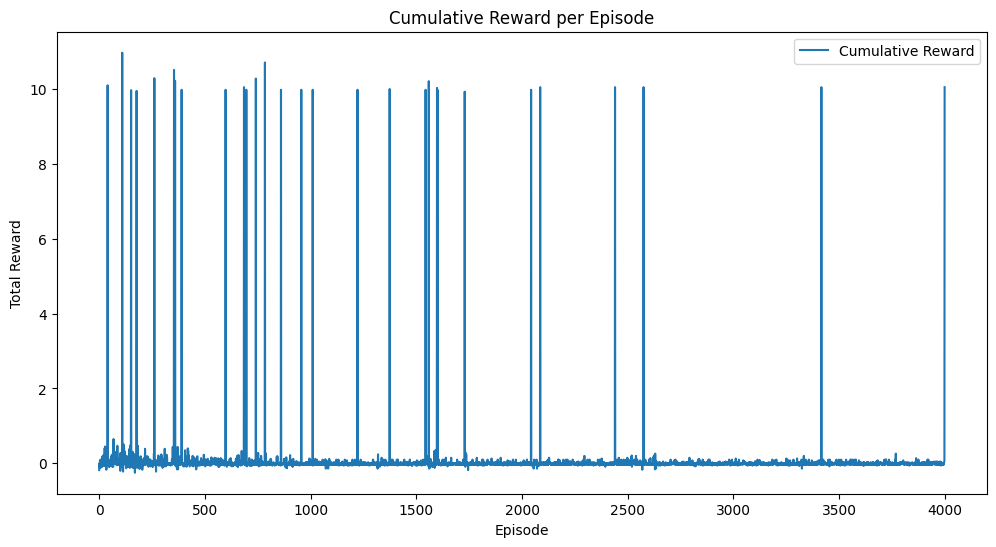

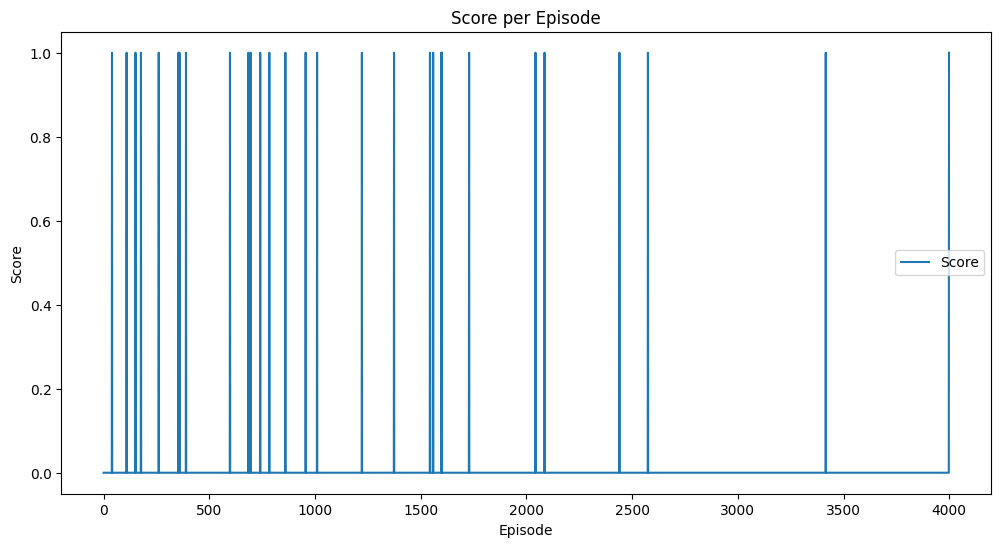

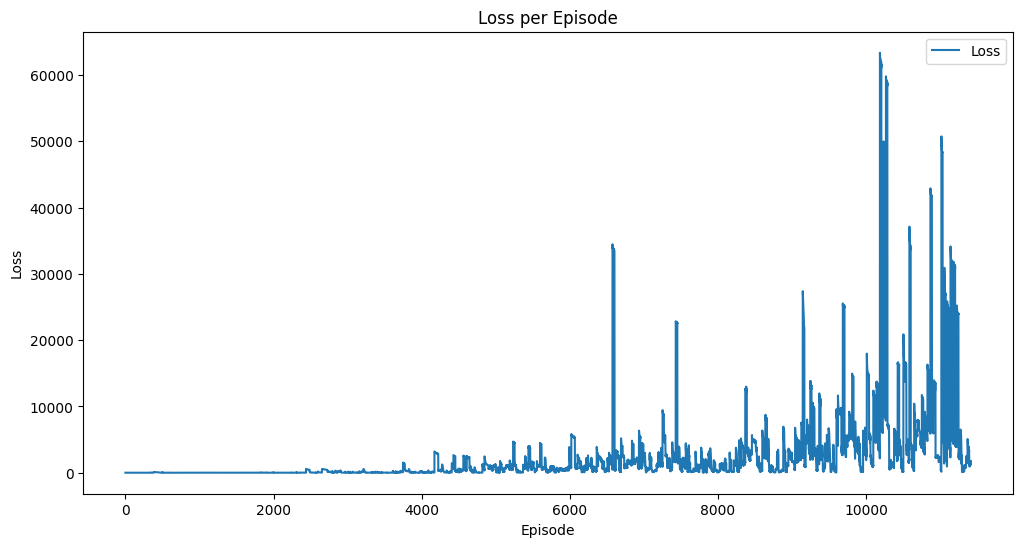

In [169]:
plot_metrics(episode_rewards, episode_scores, losses)

In [159]:
sum(episode_rewards)/len(episode_rewards)

0.0704899999999998